# Multi-Model SOH Forecast Benchmark

This notebook compares several SOH forecasting approaches on the repo's local event time-series / latent-SOH data.

The benchmark is designed to be:

- causal for forecasting inputs
- detailed enough to inspect feature behavior over time
- interpretable enough to see why a model wins or fails

Included approaches:

1. `naive_zero_delta`
2. `ridge_raw_only`
3. `ridge_raw_plus_latent`
4. `ridge_raw_plus_latent_plus_history`
5. `gbdt_raw_plus_latent_plus_history`
6. `lstm_sequence`
7. `physics_informed_nn`

Target:

- `next_latent_soh_smooth_pct`

Interpretation strategy:

- engineer raw, latent, lag, rolling, and stress-history features
- compare tabular and sequence models
- inspect top correlations, ridge coefficients, permutation importance, learning curves, and chronological forecasts

The "physics-informed" model here is not a full PDE PINN. It is a forecasting network with battery-aging structure built into the output:

- next SOH is modeled as current SOH minus a non-negative degradation magnitude
- elapsed time and stress can only increase the degradation magnitude contribution

That makes it an interpretable physics-informed surrogate for irreversible degradation.


## Setup

In [16]:
from pathlib import Path
import json
import math
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "ml_workspace").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate repo root")


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml_workspace.latent_soh.build_latent_soh import build_latent_soh_labels

set_seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 240)

PRIMARY_PLANE = "166"
HOLDOUT_PLANE = "192"
RUN_LATENT_PIPELINE = False
RT_PROFILE = "balanced"
Q_DAY_SIGMA_PCT = 0.05
COMPARE_BACKEND = True

TRAIN_FRAC = 0.70
VALID_FRAC = 0.15
LOOKBACK = 12
DEVICE = torch.device("cpu")

LATENT_ROOT = REPO_ROOT / "ml_workspace" / "latent_soh" / "output"
OUTPUT_DIR = REPO_ROOT / "ml_workspace" / "soh_forecast" / "output" / f"multimodel_benchmark_plane_{PRIMARY_PLANE}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_CANDIDATES = [
    REPO_ROOT / "data" / "event_timeseries_corrected.parquet",
    REPO_ROOT / "data" / "event_timeseries.parquet",
]
TIMESERIES_PATH = next((p for p in TIMESERIES_CANDIDATES if p.exists()), None)
SPEC_PATH = REPO_ROOT / "ml_workspace" / "battery_specs.yaml"

print("Repo root:", REPO_ROOT)
print("Latent root:", LATENT_ROOT)
print("Output dir:", OUTPUT_DIR)
print("Torch version:", torch.__version__)


Repo root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane
Latent root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/latent_soh/output
Output dir: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/output/multimodel_benchmark_plane_166
Torch version: 2.10.0


## 1. Load or build latent SOH event tables

In [17]:
def ensure_latent_outputs(plane_id: str) -> Path:
    plane_dir = LATENT_ROOT / f"plane_{plane_id}"
    latent_csv = plane_dir / "latent_soh_event_table.csv"
    if latent_csv.exists():
        return plane_dir
    if not RUN_LATENT_PIPELINE:
        raise FileNotFoundError(f"Missing latent output for plane {plane_id}: {latent_csv}")
    if TIMESERIES_PATH is None:
        raise FileNotFoundError("No local event_timeseries parquet found")
    plane_dir.mkdir(parents=True, exist_ok=True)
    result = build_latent_soh_labels(
        plane_id=plane_id,
        timeseries_path=TIMESERIES_PATH,
        spec_path=SPEC_PATH,
        output_dir=plane_dir,
        q_day_sigma_pct=Q_DAY_SIGMA_PCT,
        rt_profile=RT_PROFILE,
    )
    print(json.dumps(result, indent=2))
    return plane_dir


def load_plane_latent(plane_id: str) -> tuple[pd.DataFrame, dict]:
    plane_dir = ensure_latent_outputs(plane_id)
    latent_df = pd.read_csv(plane_dir / "latent_soh_event_table.csv", parse_dates=["event_datetime"])
    summary = json.loads((plane_dir / "diagnostics" / "smoother_summary.json").read_text())
    latent_df["plane_id"] = latent_df["plane_id"].astype(str)
    latent_df["battery_id"] = pd.to_numeric(latent_df["battery_id"], errors="coerce")
    return latent_df, summary


primary_latent_df, primary_summary = load_plane_latent(PRIMARY_PLANE)
holdout_latent_df = pd.DataFrame()
holdout_summary = None
if (LATENT_ROOT / f"plane_{HOLDOUT_PLANE}" / "latent_soh_event_table.csv").exists() or RUN_LATENT_PIPELINE:
    holdout_latent_df, holdout_summary = load_plane_latent(HOLDOUT_PLANE)

display(pd.DataFrame([primary_summary]))
if holdout_summary is not None:
    display(pd.DataFrame([holdout_summary]))

latent_df = pd.concat([primary_latent_df, holdout_latent_df], ignore_index=True)
latent_df["battery_id_str"] = latent_df["battery_id"].astype("Int64").astype(str)
latent_df["event_id"] = (
    latent_df["plane_id"].astype(str)
    + "_"
    + latent_df["battery_id_str"]
    + "_"
    + latent_df["flight_id"].astype(str)
    + "_"
    + latent_df["event_datetime"].dt.strftime("%Y%m%d%H%M%S")
)

print("Rows loaded:", len(latent_df))
display(
    latent_df.groupby(["plane_id", "battery_id"], as_index=False).agg(
        n_events=("flight_id", "count"),
        observed_soh_min=("observed_soh_pct", "min"),
        observed_soh_max=("observed_soh_pct", "max"),
        latent_filter_min=("latent_soh_filter_pct", "min"),
        latent_filter_max=("latent_soh_filter_pct", "max"),
        latent_smooth_min=("latent_soh_smooth_pct", "min"),
        latent_smooth_max=("latent_soh_smooth_pct", "max"),
    ).round(3)
)


,plane_id,rt_profile,battery_ids_processed,n_events_total,n_events_per_battery,n_events_dropped_missing_observed_soh,sigma_base_pct_per_battery,q_day_sigma_pct,raw_total_variation_per_battery,smoothed_total_variation_per_battery,raw_max_upward_jump_pct_per_battery,smoothed_max_upward_jump_pct_per_battery,fraction_events_with_condition_multiplier_gt_3,notes
0,166,balanced,"[1, 2]",1106,"{'1': 553, '2': 553}",0,"{'1': 0.55, '2': 0.55}",0.05,"{'1': 484.0, '2': 469.0}","{'1': 51.14722851352783, '2': 49.6942665930803}","{'1': 29.0, '2': 25.0}","{'1': 1.0244025838651254, '2': 1.0229620160775...","{'1': 0.2766726943942134, '2': 0.2567811934900...",FilterPy latent SOH is the canonical output. P...


,plane_id,rt_profile,battery_ids_processed,n_events_total,n_events_per_battery,n_events_dropped_missing_observed_soh,sigma_base_pct_per_battery,q_day_sigma_pct,raw_total_variation_per_battery,smoothed_total_variation_per_battery,raw_max_upward_jump_pct_per_battery,smoothed_max_upward_jump_pct_per_battery,fraction_events_with_condition_multiplier_gt_3,notes
0,192,balanced,"[1, 2]",98,"{'1': 49, '2': 49}",0,"{'1': 0.55, '2': 0.55}",0.05,"{'1': 5.0, '2': 5.0}","{'1': 0.8559490722647354, '2': 0.7980700292446...","{'1': 0.0, '2': 0.0}","{'1': -1.2547329788503703e-06, '2': -1.1689867...","{'1': 0.10204081632653061, '2': 0.102040816326...",FilterPy latent SOH is the canonical output. P...


Rows loaded: 1204


,plane_id,battery_id,n_events,observed_soh_min,observed_soh_max,latent_filter_min,latent_filter_max,latent_smooth_min,latent_smooth_max
0,166,1,553,40.0,100.0,52.819,99.976,52.819,96.545
1,166,2,553,42.0,100.0,55.932,99.977,55.932,96.847
2,192,1,49,95.0,100.0,96.972,99.993,96.972,97.828
3,192,2,49,95.0,100.0,97.143,99.993,97.143,97.941


## 2. Visual sanity check: observed SOH vs latent SOH

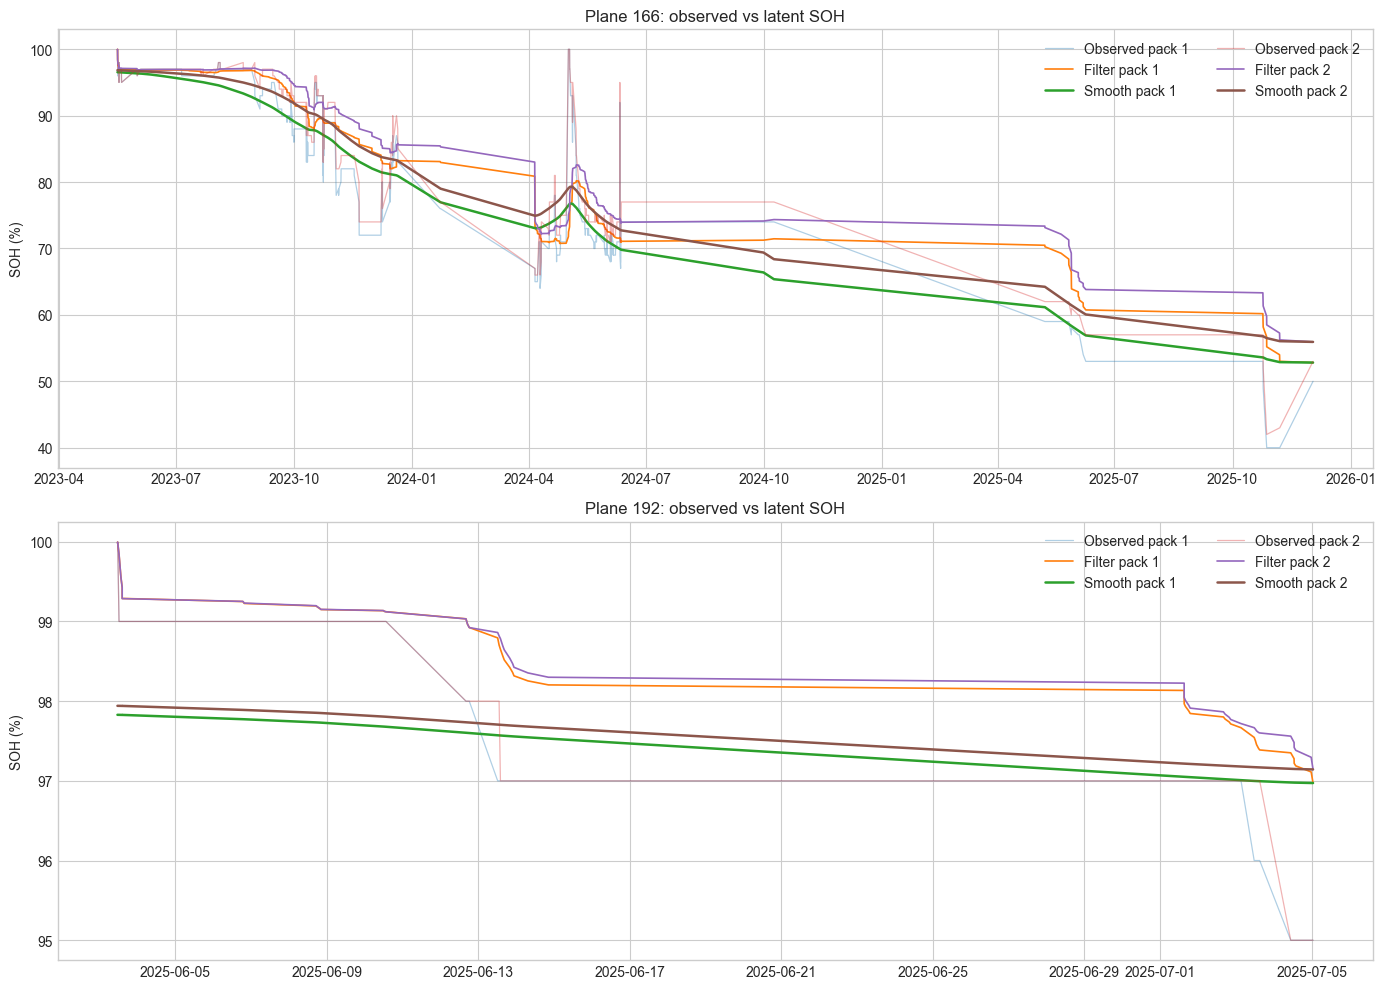

In [18]:
planes_to_plot = [PRIMARY_PLANE] + ([HOLDOUT_PLANE] if not holdout_latent_df.empty else [])
nrows = max(1, len(planes_to_plot))
fig, axes = plt.subplots(nrows, 1, figsize=(14, 5 * nrows), sharex=False)
axes = np.atleast_1d(axes)

for ax, plane_id in zip(axes, planes_to_plot):
    plane_view = latent_df.loc[latent_df["plane_id"] == plane_id].copy()
    plane_view = plane_view.sort_values(["event_datetime", "battery_id", "flight_id"])
    for battery_id, group in plane_view.groupby("battery_id", sort=True):
        g = group.sort_values(["event_datetime", "flight_id"])
        ax.plot(g["event_datetime"], g["observed_soh_pct"], linewidth=0.9, alpha=0.35, label=f"Observed pack {battery_id}")
        ax.plot(g["event_datetime"], g["latent_soh_filter_pct"], linewidth=1.2, label=f"Filter pack {battery_id}")
        ax.plot(g["event_datetime"], g["latent_soh_smooth_pct"], linewidth=1.8, label=f"Smooth pack {battery_id}")
    ax.set_title(f"Plane {plane_id}: observed vs latent SOH")
    ax.set_ylabel("SOH (%)")
    ax.legend(loc="best", ncol=2)
fig.tight_layout()


## 3. Build causal forecasting features

In [19]:
def add_forecast_features(df: pd.DataFrame) -> pd.DataFrame:
    out_frames = []
    for (plane_id, battery_id), group in df.groupby(["plane_id", "battery_id"], sort=False):
        g = group.sort_values(["event_datetime", "flight_id"]).copy()

        numeric_cols = [
            "observed_soh_pct",
            "latent_soh_filter_pct",
            "latent_soh_filterpy_filter_pct",
            "_filterpy_pred_state_pct",
            "_filterpy_pred_var_pct2",
            "measurement_sigma_pct",
            "condition_multiplier",
            "current_abs_mean_a",
            "p95_abs_current_a",
            "avg_cell_temp_mean_c",
            "avg_cell_temp_span_c",
            "soc_mean_pct",
            "soc_span_pct",
            "event_duration_s",
            "delta_days",
        ]
        for col in numeric_cols:
            if col in g.columns:
                g[col] = pd.to_numeric(g[col], errors="coerce")

        g["event_index"] = np.arange(len(g), dtype=int)
        g["flight_event_flag"] = g["event_type"].astype(str).str.lower().eq("flight").astype(int)
        g["charge_event_flag"] = g["event_type"].astype(str).str.lower().eq("charge").astype(int)
        g["other_event_flag"] = g["event_type"].astype(str).str.lower().eq("other").astype(int)
        g["cumulative_event_count"] = np.arange(1, len(g) + 1, dtype=int)
        g["cumulative_flight_count"] = g["flight_event_flag"].cumsum()

        g["time_since_prev_event_days"] = g["event_datetime"].diff().dt.total_seconds().div(86400.0)
        g["prev_delta_days"] = g["delta_days"].shift(1)

        g["prev_observed_soh_pct"] = g["observed_soh_pct"].shift(1)
        g["prev_latent_filter_pct"] = g["latent_soh_filter_pct"].shift(1)
        g["prev2_latent_filter_pct"] = g["latent_soh_filter_pct"].shift(2)
        g["prev3_latent_filter_pct"] = g["latent_soh_filter_pct"].shift(3)

        g["observed_soh_delta_1"] = g["observed_soh_pct"] - g["prev_observed_soh_pct"]
        g["latent_filter_delta_1"] = g["latent_soh_filter_pct"] - g["prev_latent_filter_pct"]
        g["latent_filter_delta_2"] = g["prev_latent_filter_pct"] - g["prev2_latent_filter_pct"]
        g["latent_filter_delta_3"] = g["prev2_latent_filter_pct"] - g["prev3_latent_filter_pct"]
        g["latent_filter_slope_pct_per_day_1"] = g["latent_filter_delta_1"] / g["time_since_prev_event_days"].clip(lower=1e-3)

        g["rolling_latent_filter_mean_3"] = g["latent_soh_filter_pct"].shift(1).rolling(3, min_periods=1).mean()
        g["rolling_latent_filter_std_3"] = g["latent_soh_filter_pct"].shift(1).rolling(3, min_periods=1).std()
        g["rolling_latent_filter_delta_mean_5"] = g["latent_filter_delta_1"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_latent_filter_delta_std_5"] = g["latent_filter_delta_1"].shift(1).rolling(5, min_periods=1).std()

        g["rolling_current_abs_mean_5"] = g["current_abs_mean_a"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_current_abs_max_5"] = g["p95_abs_current_a"].shift(1).rolling(5, min_periods=1).max()
        g["rolling_temp_mean_5"] = g["avg_cell_temp_mean_c"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_temp_span_mean_5"] = g["avg_cell_temp_span_c"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_soc_mean_5"] = g["soc_mean_pct"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_soc_span_mean_5"] = g["soc_span_pct"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_duration_mean_5"] = g["event_duration_s"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_sigma_mean_5"] = g["measurement_sigma_pct"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_condition_mean_5"] = g["condition_multiplier"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_gap_days_mean_5"] = g["time_since_prev_event_days"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_flight_frac_5"] = g["flight_event_flag"].shift(1).rolling(5, min_periods=1).mean()

        g["current_temp_stress_index"] = g["current_abs_mean_a"].clip(lower=0.0) * g["avg_cell_temp_mean_c"].clip(lower=0.0)
        g["soc_stress_index"] = g["soc_mean_pct"].clip(lower=0.0) * g["soc_span_pct"].clip(lower=0.0)
        g["duration_stress_index"] = g["event_duration_s"].clip(lower=0.0) * g["condition_multiplier"].clip(lower=0.0)
        g["instant_stress_index"] = g["current_temp_stress_index"] + g["soc_stress_index"] + 0.001 * g["duration_stress_index"]
        g["rolling_stress_index_mean_5"] = g["instant_stress_index"].shift(1).rolling(5, min_periods=1).mean()
        g["rolling_stress_index_max_5"] = g["instant_stress_index"].shift(1).rolling(5, min_periods=1).max()

        g["next_latent_soh_smooth_pct"] = g["latent_soh_filter_pct"].shift(-1)
        g["next_observed_soh_pct"] = g["observed_soh_pct"].shift(-1)
        g["next_latent_delta_pct"] = g["next_latent_soh_smooth_pct"] - g["latent_soh_filter_pct"]

        out_frames.append(g)

    out = pd.concat(out_frames, ignore_index=True)
    zero_fill_cols = [
        "rolling_latent_filter_std_3",
        "rolling_latent_filter_delta_std_5",
    ]
    for col in zero_fill_cols:
        if col in out.columns:
            out[col] = out[col].fillna(0.0)
    return out


work = add_forecast_features(latent_df)
predictive_df = work.loc[work["next_latent_soh_smooth_pct"].notna()].copy()

raw_feature_cols = [
    "observed_soh_pct",
    "current_abs_mean_a",
    "p95_abs_current_a",
    "avg_cell_temp_mean_c",
    "avg_cell_temp_span_c",
    "soc_mean_pct",
    "soc_span_pct",
    "event_duration_s",
    "measurement_sigma_pct",
    "condition_multiplier",
    "delta_days",
    "flight_event_flag",
    "charge_event_flag",
    "cumulative_event_count",
    "cumulative_flight_count",
]

latent_feature_cols = [
    "latent_soh_filter_pct",
    "latent_soh_filterpy_filter_pct",
    "_filterpy_pred_state_pct",
    "_filterpy_pred_var_pct2",
    "measurement_sigma_pct",
    "condition_multiplier",
]

history_feature_cols = [
    "prev_observed_soh_pct",
    "prev_latent_filter_pct",
    "prev2_latent_filter_pct",
    "prev3_latent_filter_pct",
    "prev_delta_days",
    "time_since_prev_event_days",
    "observed_soh_delta_1",
    "latent_filter_delta_1",
    "latent_filter_delta_2",
    "latent_filter_delta_3",
    "latent_filter_slope_pct_per_day_1",
    "rolling_latent_filter_mean_3",
    "rolling_latent_filter_std_3",
    "rolling_latent_filter_delta_mean_5",
    "rolling_latent_filter_delta_std_5",
    "rolling_current_abs_mean_5",
    "rolling_current_abs_max_5",
    "rolling_temp_mean_5",
    "rolling_temp_span_mean_5",
    "rolling_soc_mean_5",
    "rolling_soc_span_mean_5",
    "rolling_duration_mean_5",
    "rolling_sigma_mean_5",
    "rolling_condition_mean_5",
    "rolling_gap_days_mean_5",
    "rolling_flight_frac_5",
    "current_temp_stress_index",
    "soc_stress_index",
    "duration_stress_index",
    "instant_stress_index",
    "rolling_stress_index_mean_5",
    "rolling_stress_index_max_5",
]

available_raw = [c for c in raw_feature_cols if c in predictive_df.columns]
available_latent = [c for c in latent_feature_cols if c in predictive_df.columns]
available_history = [c for c in history_feature_cols if c in predictive_df.columns]

display(
    predictive_df[
        [
            "plane_id",
            "battery_id",
            "event_datetime",
            "latent_soh_filter_pct",
            "rolling_latent_filter_delta_mean_5",
            "rolling_stress_index_mean_5",
            "next_latent_soh_smooth_pct",
            "next_latent_delta_pct",
        ]
    ].head(12).round(4)
)


,plane_id,battery_id,event_datetime,latent_soh_filter_pct,rolling_latent_filter_delta_mean_5,rolling_stress_index_mean_5,next_latent_soh_smooth_pct,next_latent_delta_pct
0,166,1,2023-05-16 11:00:00,99.9509,NaN,NaN,96.5450,-3.4060
1,166,1,2023-05-16 12:44:00,99.9757,NaN,2297.9481,96.5449,-3.4308
2,166,1,2023-05-16 13:00:00,99.7066,0.0247,4023.0374,96.5442,-3.1624
3,166,1,2023-05-16 14:35:00,98.7302,-0.1222,4525.7529,96.5440,-2.1863
4,166,1,2023-05-16 15:00:00,98.4170,-0.4069,4765.1162,96.5420,-1.8750
5,166,1,2023-05-16 19:11:00,97.8292,-0.3835,4964.4240,96.5417,-1.2875
6,166,1,2023-05-16 20:00:00,97.7662,-0.4244,5697.6786,96.5411,-1.2251
7,166,1,2023-05-16 21:19:00,97.6174,-0.4419,5706.9032,96.5408,-1.0766
8,166,1,2023-05-16 22:00:00,97.5515,-0.4178,5672.5265,96.5340,-1.0175
9,166,1,2023-05-17 11:30:00,97.4231,-0.2357,4831.7207,96.5331,-0.8899


## 4. Train / validation / test split

In [20]:
def time_split(df: pd.DataFrame, train_frac: float, valid_frac: float) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    ordered = df.sort_values("event_datetime").copy()
    n = len(ordered)
    n_train = max(1, int(round(n * train_frac)))
    n_valid = max(1, int(round(n * valid_frac))) if n >= 3 else max(0, n - n_train)
    if n_train + n_valid >= n:
        n_valid = max(1, n - n_train - 1) if n >= 3 else max(0, n - n_train)
    train_df = ordered.iloc[:n_train].copy()
    valid_df = ordered.iloc[n_train : n_train + n_valid].copy()
    test_df = ordered.iloc[n_train + n_valid :].copy()
    return train_df, valid_df, test_df


predictive_df["split"] = "unused"
primary_mask = predictive_df["plane_id"].eq(PRIMARY_PLANE)
primary_rows = predictive_df.loc[primary_mask].copy()
train_primary, valid_primary, test_primary = time_split(primary_rows, TRAIN_FRAC, VALID_FRAC)

predictive_df.loc[train_primary.index, "split"] = "train"
predictive_df.loc[valid_primary.index, "split"] = "valid"
predictive_df.loc[test_primary.index, "split"] = "test"

if not holdout_latent_df.empty:
    predictive_df.loc[predictive_df["plane_id"].eq(HOLDOUT_PLANE), "split"] = "holdout"

train_df = predictive_df.loc[predictive_df["split"].eq("train")].copy()
valid_df = predictive_df.loc[predictive_df["split"].eq("valid")].copy()
test_df = predictive_df.loc[predictive_df["split"].eq("test")].copy()
holdout_df = predictive_df.loc[predictive_df["split"].eq("holdout")].copy()

print("train / valid / test / holdout:", len(train_df), len(valid_df), len(test_df), len(holdout_df))
display(
    predictive_df.groupby(["plane_id", "split"], as_index=False).agg(
        rows=("event_id", "count"),
        min_date=("event_datetime", "min"),
        max_date=("event_datetime", "max"),
    )
)


train / valid / test / holdout: 773 166 165 96


,plane_id,split,rows,min_date,max_date
0,166,test,165,2024-06-03 21:20:00,2025-11-06 19:30:00
1,166,train,773,2023-05-16 11:00:00,2024-05-17 12:06:00
2,166,valid,166,2024-05-17 12:06:00,2024-06-03 21:20:00
3,192,holdout,96,2025-06-03 11:30:00,2025-07-04 23:36:00


## 5. Feature analysis before modeling

,corr_with_next_delta,abs_corr
rolling_gap_days_mean_5,-0.3956,0.3956
latent_filter_delta_1,0.3678,0.3678
latent_filter_delta_2,0.2966,0.2966
prev_delta_days,-0.2699,0.2699
latent_filter_delta_3,0.2296,0.2296
delta_days,-0.2241,0.2241
rolling_latent_filter_delta_mean_5,0.2122,0.2122
cumulative_flight_count,-0.2101,0.2101
time_since_prev_event_days,-0.2088,0.2088
rolling_current_abs_max_5,-0.1854,0.1854


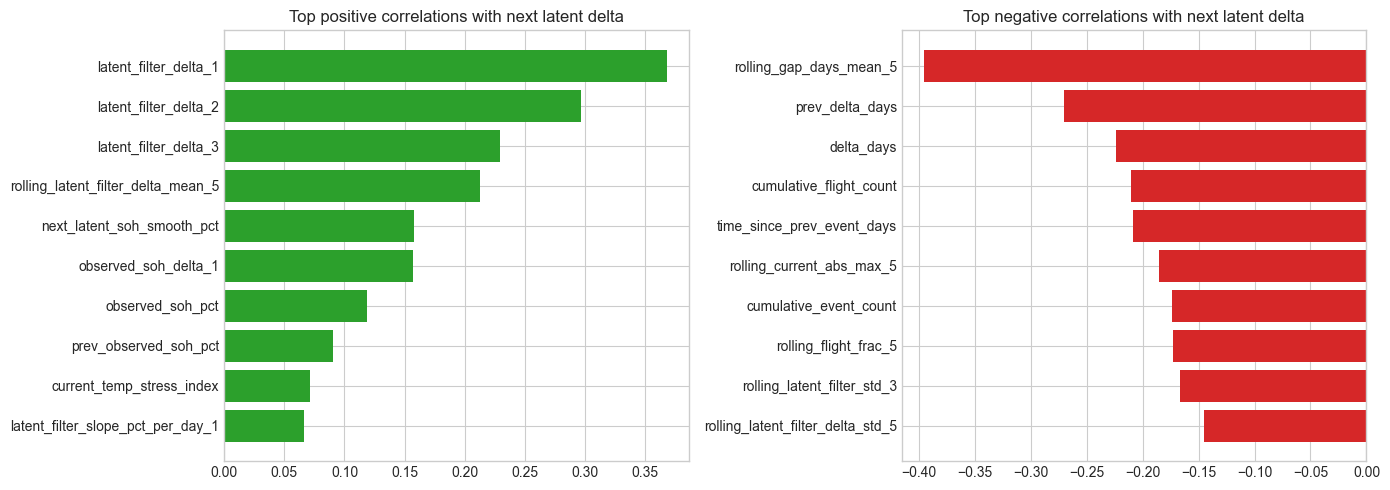

In [21]:
analysis_cols = list(dict.fromkeys(available_raw + available_latent + available_history + ["next_latent_delta_pct", "next_latent_soh_smooth_pct"]))
analysis_frame = predictive_df[analysis_cols].apply(pd.to_numeric, errors="coerce")
corr_with_delta = analysis_frame.corr(numeric_only=True)["next_latent_delta_pct"].dropna().drop("next_latent_delta_pct")
corr_df = (
    corr_with_delta.rename("corr_with_next_delta")
    .to_frame()
    .assign(abs_corr=lambda x: x["corr_with_next_delta"].abs())
    .sort_values("abs_corr", ascending=False)
)

display(corr_df.head(20).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_pos = corr_df.sort_values("corr_with_next_delta", ascending=False).head(10)
top_neg = corr_df.sort_values("corr_with_next_delta", ascending=True).head(10)
axes[0].barh(top_pos.index[::-1], top_pos["corr_with_next_delta"][::-1], color="#2ca02c")
axes[0].set_title("Top positive correlations with next latent delta")
axes[1].barh(top_neg.index[::-1], top_neg["corr_with_next_delta"][::-1], color="#d62728")
axes[1].set_title("Top negative correlations with next latent delta")
fig.tight_layout()


## 6. Tabular model helpers

In [22]:
def make_feature_frame(df: pd.DataFrame, feature_cols: list[str], medians_ref: pd.Series | None = None, dummy_cols_ref: list[str] | None = None):
    cols = list(dict.fromkeys([c for c in feature_cols if c in df.columns]))
    numeric = df[cols].apply(pd.to_numeric, errors="coerce").copy()
    medians = numeric.median().fillna(0.0) if medians_ref is None else medians_ref
    numeric = numeric.fillna(medians).fillna(0.0)

    event_dummies = pd.get_dummies(df["event_type"].fillna("unknown"), prefix="event_type")
    battery_dummies = pd.get_dummies(df["battery_id_str"].fillna("unknown"), prefix="battery")
    split_dummies = pd.get_dummies(df["plane_id"].fillna("unknown"), prefix="plane")
    dummies = pd.concat([event_dummies, battery_dummies, split_dummies], axis=1)

    if dummy_cols_ref is None:
        dummy_cols = list(dummies.columns)
    else:
        dummy_cols = list(dummy_cols_ref)
        for col in dummy_cols:
            if col not in dummies.columns:
                dummies[col] = 0
    dummies = dummies[dummy_cols]
    out = pd.concat([numeric.reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)
    return out, medians, dummy_cols


def r2_safe(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if len(y_true) == 0:
        return np.nan
    denom = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1.0 - np.sum((y_true - y_pred) ** 2) / denom) if denom > 1e-12 else np.nan


def metric_table(y_true_level: np.ndarray, y_pred_level: np.ndarray, current_level: np.ndarray) -> dict[str, float]:
    y_true_delta = y_true_level - current_level
    y_pred_delta = y_pred_level - current_level
    return {
        "n": int(len(y_true_level)),
        "level_mae": float(mean_absolute_error(y_true_level, y_pred_level)),
        "level_rmse": float(np.sqrt(mean_squared_error(y_true_level, y_pred_level))),
        "level_r2": r2_safe(y_true_level, y_pred_level),
        "delta_mae": float(mean_absolute_error(y_true_delta, y_pred_delta)),
        "delta_rmse": float(np.sqrt(mean_squared_error(y_true_delta, y_pred_delta))),
        "delta_r2": r2_safe(y_true_delta, y_pred_delta),
    }


def fit_best_linear(model_cls, X_train, y_train, X_valid, y_valid, grid):
    best_model = None
    best_score = np.inf
    for params in grid:
        model = model_cls(**params)
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        score = mean_absolute_error(y_valid, pred)
        if score < best_score:
            best_model = model
            best_score = score
    return best_model


def train_tabular_model(model_name: str, feature_cols: list[str], estimator: str):
    train_x, medians, dummy_cols = make_feature_frame(train_df, feature_cols)
    valid_x, _, _ = make_feature_frame(valid_df, feature_cols, medians, dummy_cols)
    test_x, _, _ = make_feature_frame(test_df, feature_cols, medians, dummy_cols)
    holdout_x, _, _ = make_feature_frame(holdout_df, feature_cols, medians, dummy_cols) if not holdout_df.empty else (pd.DataFrame(), medians, dummy_cols)

    y_train_level = train_df["next_latent_soh_smooth_pct"].to_numpy(dtype=float)
    y_valid_level = valid_df["next_latent_soh_smooth_pct"].to_numpy(dtype=float)
    y_test_level = test_df["next_latent_soh_smooth_pct"].to_numpy(dtype=float)
    y_holdout_level = holdout_df["next_latent_soh_smooth_pct"].to_numpy(dtype=float) if not holdout_df.empty else np.array([], dtype=float)

    current_train = train_df["latent_soh_filter_pct"].to_numpy(dtype=float)
    current_valid = valid_df["latent_soh_filter_pct"].to_numpy(dtype=float)
    current_test = test_df["latent_soh_filter_pct"].to_numpy(dtype=float)
    current_holdout = holdout_df["latent_soh_filter_pct"].to_numpy(dtype=float) if not holdout_df.empty else np.array([], dtype=float)

    y_train_delta = y_train_level - current_train
    y_valid_delta = y_valid_level - current_valid

    scaler = StandardScaler()
    train_x_s = scaler.fit_transform(train_x)
    valid_x_s = scaler.transform(valid_x)
    test_x_s = scaler.transform(test_x)
    holdout_x_s = scaler.transform(holdout_x) if not holdout_df.empty else np.empty((0, train_x.shape[1]))

    if estimator == "ridge":
        model = fit_best_linear(Ridge, train_x_s, y_train_delta, valid_x_s, y_valid_delta, [{"alpha": a} for a in [0.01, 0.1, 1.0, 10.0, 100.0]])
        predict_fn = lambda Xs, Xraw: model.predict(Xs)
    elif estimator == "elastic":
        grid = [{"alpha": a, "l1_ratio": l1} for a in [0.001, 0.01, 0.1, 1.0] for l1 in [0.1, 0.5, 0.9]]
        model = fit_best_linear(ElasticNet, train_x_s, y_train_delta, valid_x_s, y_valid_delta, grid)
        predict_fn = lambda Xs, Xraw: model.predict(Xs)
    elif estimator == "gbdt":
        best_model = None
        best_score = np.inf
        for params in [
            {"learning_rate": 0.03, "max_depth": 3, "max_iter": 300, "min_samples_leaf": 10, "random_state": 42},
            {"learning_rate": 0.05, "max_depth": 4, "max_iter": 300, "min_samples_leaf": 10, "random_state": 42},
            {"learning_rate": 0.05, "max_depth": 3, "max_iter": 500, "min_samples_leaf": 5, "random_state": 42},
        ]:
            candidate = HistGradientBoostingRegressor(**params)
            candidate.fit(train_x, y_train_delta)
            score = mean_absolute_error(y_valid_delta, candidate.predict(valid_x))
            if score < best_score:
                best_model = candidate
                best_score = score
        model = best_model
        predict_fn = lambda Xs, Xraw: model.predict(Xraw)
    else:
        raise ValueError(estimator)

    pred_train_level = current_train + predict_fn(train_x_s, train_x)
    pred_valid_level = current_valid + predict_fn(valid_x_s, valid_x)
    pred_test_level = current_test + predict_fn(test_x_s, test_x)
    pred_holdout_level = current_holdout + predict_fn(holdout_x_s, holdout_x) if not holdout_df.empty else np.array([], dtype=float)

    predictions = pd.concat(
        [
            pd.DataFrame({"event_id": train_df["event_id"], "split": "train", model_name: pred_train_level}),
            pd.DataFrame({"event_id": valid_df["event_id"], "split": "valid", model_name: pred_valid_level}),
            pd.DataFrame({"event_id": test_df["event_id"], "split": "test", model_name: pred_test_level}),
            pd.DataFrame({"event_id": holdout_df["event_id"], "split": "holdout", model_name: pred_holdout_level}) if not holdout_df.empty else pd.DataFrame(columns=["event_id", "split", model_name]),
        ],
        ignore_index=True,
    )

    metrics_rows = [
        {"model": model_name, "eval_split": "train", **metric_table(y_train_level, pred_train_level, current_train)},
        {"model": model_name, "eval_split": "valid", **metric_table(y_valid_level, pred_valid_level, current_valid)},
        {"model": model_name, "eval_split": "test", **metric_table(y_test_level, pred_test_level, current_test)},
    ]
    if not holdout_df.empty:
        metrics_rows.append({"model": model_name, "eval_split": "holdout", **metric_table(y_holdout_level, pred_holdout_level, current_holdout)})

    info = {
        "model": model,
        "feature_names": list(train_x.columns),
        "train_frame": train_x,
        "test_frame": test_x,
        "test_target_level": y_test_level,
        "test_current": current_test,
        "scaler": scaler,
    }
    return pd.DataFrame(metrics_rows), predictions, info


## 7. Train tabular baselines and latent/history models

In [23]:
feature_sets = {
    "ridge_raw_only": available_raw,
    "ridge_raw_plus_latent": available_raw + available_latent,
    "elastic_raw_plus_latent_plus_history": available_raw + available_latent + available_history,
    "ridge_raw_plus_latent_plus_history": available_raw + available_latent + available_history,
    "gbdt_raw_plus_latent_plus_history": available_raw + available_latent + available_history,
}

prediction_tables = []
metric_tables = []
model_artifacts = {}

naive_predictions = pd.concat(
    [
        pd.DataFrame({
            "event_id": train_df["event_id"],
            "split": "train",
            "naive_zero_delta": train_df["latent_soh_filter_pct"].to_numpy(dtype=float),
        }),
        pd.DataFrame({
            "event_id": valid_df["event_id"],
            "split": "valid",
            "naive_zero_delta": valid_df["latent_soh_filter_pct"].to_numpy(dtype=float),
        }),
        pd.DataFrame({
            "event_id": test_df["event_id"],
            "split": "test",
            "naive_zero_delta": test_df["latent_soh_filter_pct"].to_numpy(dtype=float),
        }),
        pd.DataFrame({
            "event_id": holdout_df["event_id"],
            "split": "holdout",
            "naive_zero_delta": holdout_df["latent_soh_filter_pct"].to_numpy(dtype=float),
        }) if not holdout_df.empty else pd.DataFrame(columns=["event_id", "split", "naive_zero_delta"]),
    ],
    ignore_index=True,
)
naive_metrics = pd.DataFrame(
    [
        {"model": "naive_zero_delta", "eval_split": "train", **metric_table(train_df["next_latent_soh_smooth_pct"].to_numpy(dtype=float), train_df["latent_soh_filter_pct"].to_numpy(dtype=float), train_df["latent_soh_filter_pct"].to_numpy(dtype=float))},
        {"model": "naive_zero_delta", "eval_split": "valid", **metric_table(valid_df["next_latent_soh_smooth_pct"].to_numpy(dtype=float), valid_df["latent_soh_filter_pct"].to_numpy(dtype=float), valid_df["latent_soh_filter_pct"].to_numpy(dtype=float))},
        {"model": "naive_zero_delta", "eval_split": "test", **metric_table(test_df["next_latent_soh_smooth_pct"].to_numpy(dtype=float), test_df["latent_soh_filter_pct"].to_numpy(dtype=float), test_df["latent_soh_filter_pct"].to_numpy(dtype=float))},
    ]
)
if not holdout_df.empty:
    naive_metrics = pd.concat(
        [
            naive_metrics,
            pd.DataFrame(
                [
                    {"model": "naive_zero_delta", "eval_split": "holdout", **metric_table(holdout_df["next_latent_soh_smooth_pct"].to_numpy(dtype=float), holdout_df["latent_soh_filter_pct"].to_numpy(dtype=float), holdout_df["latent_soh_filter_pct"].to_numpy(dtype=float))}
                ]
            ),
        ],
        ignore_index=True,
    )
prediction_tables.append(naive_predictions)
metric_tables.append(naive_metrics)

for model_name, feature_cols in feature_sets.items():
    estimator = "ridge" if model_name.startswith("ridge") else ("elastic" if model_name.startswith("elastic") else "gbdt")
    metrics_df, pred_df, artifact = train_tabular_model(model_name, feature_cols, estimator)
    metric_tables.append(metrics_df)
    prediction_tables.append(pred_df)
    model_artifacts[model_name] = artifact

tabular_metrics = pd.concat(metric_tables, ignore_index=True)
all_predictions = naive_predictions.copy()
for pred_df in prediction_tables[1:]:
    all_predictions = all_predictions.merge(pred_df, on=["event_id", "split"], how="outer")

display(tabular_metrics.round(4))


/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.215e+02, tolerance: 4.882e-01
  model = cd_fast.enet_coordinate_descent(
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.557e+01, tolerance: 4.882e-01
  model = cd_fast.enet_coordinate_descent(
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might wa

,model,eval_split,n,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,train,773,2.5627,2.9142,0.8636,2.5627,2.9142,-0.3447
1,naive_zero_delta,valid,166,1.9708,2.0151,-0.6547,1.9708,2.0151,-21.9898
2,naive_zero_delta,test,165,3.4447,4.4370,0.6041,3.4447,4.4370,-1.5171
3,naive_zero_delta,holdout,96,1.0075,1.1186,-10.2009,1.0075,1.1186,-4.2983
4,ridge_raw_only,train,773,1.7142,2.1935,0.9227,1.7142,2.1935,0.2382
5,ridge_raw_only,valid,166,0.6245,0.7994,0.7396,0.6245,0.7994,-2.6178
6,ridge_raw_only,test,165,2.4488,3.2877,0.7826,2.4488,3.2877,-0.3820
7,ridge_raw_only,holdout,96,1.3463,1.5475,-20.4371,1.3463,1.5475,-9.1404
8,ridge_raw_plus_latent,train,773,0.9482,1.2346,0.9755,0.9482,1.2346,0.7587
9,ridge_raw_plus_latent,valid,166,0.8230,0.9868,0.6032,0.8230,0.9868,-4.5128


## 8. Sequence model: LSTM over event history

In [24]:
sequence_feature_cols = list(
    dict.fromkeys(
        available_raw
        + available_latent
        + [
            "prev_latent_filter_pct",
            "latent_filter_delta_1",
            "latent_filter_slope_pct_per_day_1",
            "rolling_latent_filter_delta_mean_5",
            "rolling_current_abs_mean_5",
            "rolling_temp_mean_5",
            "rolling_soc_span_mean_5",
            "rolling_sigma_mean_5",
            "rolling_condition_mean_5",
            "rolling_stress_index_mean_5",
            "rolling_gap_days_mean_5",
        ]
    )
)

train_seq_base = train_df[sequence_feature_cols].apply(pd.to_numeric, errors="coerce")
seq_medians = train_seq_base.median().fillna(0.0)
seq_means = train_seq_base.fillna(seq_medians).mean()
seq_stds = train_seq_base.fillna(seq_medians).std().replace(0.0, 1.0).fillna(1.0)

seq_work = predictive_df.copy()
seq_work[sequence_feature_cols] = (
    seq_work[sequence_feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(seq_medians)
)
seq_work[sequence_feature_cols] = (seq_work[sequence_feature_cols] - seq_means) / seq_stds


def build_sequence_arrays(df: pd.DataFrame, feature_cols: list[str], lookback: int):
    rows = []
    for (plane_id, battery_id), group in df.groupby(["plane_id", "battery_id"], sort=False):
        g = group.sort_values(["event_datetime", "flight_id"]).reset_index(drop=True)
        if len(g) < lookback:
            continue
        feature_frame = g[feature_cols]
        for idx in range(lookback - 1, len(g)):
            split = g.loc[idx, "split"]
            if split not in {"train", "valid", "test", "holdout"}:
                continue
            target = g.loc[idx, "next_latent_soh_smooth_pct"]
            current = g.loc[idx, "latent_soh_filter_pct"]
            if pd.isna(target) or pd.isna(current):
                continue
            window = feature_frame.iloc[idx - lookback + 1 : idx + 1].to_numpy(dtype=float)
            if np.isnan(window).any():
                continue
            rows.append(
                {
                    "event_id": g.loc[idx, "event_id"],
                    "split": split,
                    "plane_id": plane_id,
                    "battery_id": battery_id,
                    "X": window,
                    "y_level": float(target),
                    "current_level": float(current),
                }
            )
    return rows


seq_rows = build_sequence_arrays(seq_work, sequence_feature_cols, LOOKBACK)
print("Sequence samples:", len(seq_rows))
display(pd.Series([row["split"] for row in seq_rows]).value_counts())


class LSTMForecaster(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, dropout=dropout, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)


def rows_to_loader(rows: list[dict], split_name: str, batch_size: int, shuffle: bool):
    subset = [row for row in rows if row["split"] == split_name]
    if not subset:
        return None, subset
    X = torch.tensor(np.stack([row["X"] for row in subset]), dtype=torch.float32)
    y = torch.tensor(np.array([row["y_level"] for row in subset], dtype=float), dtype=torch.float32)
    current = torch.tensor(np.array([row["current_level"] for row in subset], dtype=float), dtype=torch.float32)
    dataset = TensorDataset(X, y, current)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle), subset


lstm_train_loader, lstm_train_rows = rows_to_loader(seq_rows, "train", 32, True)
lstm_valid_loader, lstm_valid_rows = rows_to_loader(seq_rows, "valid", 64, False)
lstm_test_loader, lstm_test_rows = rows_to_loader(seq_rows, "test", 64, False)
lstm_holdout_loader, lstm_holdout_rows = rows_to_loader(seq_rows, "holdout", 64, False)

lstm_history = []
lstm_model = LSTMForecaster(len(sequence_feature_cols)).to(DEVICE)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
lstm_loss_fn = nn.MSELoss()

if lstm_train_loader is not None and lstm_valid_loader is not None:
    best_state = None
    best_valid_mae = np.inf
    patience = 8
    epochs_no_improve = 0

    for epoch in range(1, 41):
        lstm_model.train()
        train_losses = []
        for xb, yb, _current in lstm_train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            lstm_optimizer.zero_grad()
            pred = lstm_model(xb)
            loss = lstm_loss_fn(pred, yb)
            loss.backward()
            lstm_optimizer.step()
            train_losses.append(float(loss.item()))

        lstm_model.eval()
        with torch.no_grad():
            valid_preds = []
            valid_true = []
            for xb, yb, _current in lstm_valid_loader:
                pred = lstm_model(xb.to(DEVICE)).cpu().numpy()
                valid_preds.append(pred)
                valid_true.append(yb.numpy())
        valid_pred = np.concatenate(valid_preds)
        valid_true = np.concatenate(valid_true)
        valid_mae = mean_absolute_error(valid_true, valid_pred)
        lstm_history.append({"epoch": epoch, "train_loss": float(np.mean(train_losses)), "valid_mae": float(valid_mae)})

        if valid_mae < best_valid_mae:
            best_valid_mae = valid_mae
            best_state = {k: v.detach().cpu().clone() for k, v in lstm_model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    if best_state is not None:
        lstm_model.load_state_dict(best_state)


def predict_lstm(loader, subset_rows):
    if loader is None or not subset_rows:
        return pd.DataFrame(columns=["event_id", "split", "lstm_sequence"])
    preds = []
    with torch.no_grad():
        for xb, _yb, _current in loader:
            pred = lstm_model(xb.to(DEVICE)).cpu().numpy()
            preds.append(pred)
    pred_values = np.concatenate(preds)
    return pd.DataFrame(
        {
            "event_id": [row["event_id"] for row in subset_rows],
            "split": [row["split"] for row in subset_rows],
            "lstm_sequence": pred_values,
        }
    )


lstm_predictions = pd.concat(
    [
        predict_lstm(lstm_train_loader, lstm_train_rows),
        predict_lstm(lstm_valid_loader, lstm_valid_rows),
        predict_lstm(lstm_test_loader, lstm_test_rows),
        predict_lstm(lstm_holdout_loader, lstm_holdout_rows),
    ],
    ignore_index=True,
)

lstm_history_df = pd.DataFrame(lstm_history)
all_predictions = all_predictions.merge(lstm_predictions, on=["event_id", "split"], how="left")


def metrics_from_prediction_df(model_name: str, pred_col: str) -> pd.DataFrame:
    rows = []
    for split_name, split_frame in [("train", train_df), ("valid", valid_df), ("test", test_df), ("holdout", holdout_df)]:
        if split_frame.empty:
            continue
        pred_frame = all_predictions.loc[(all_predictions["split"] == split_name) & all_predictions[pred_col].notna(), ["event_id", pred_col]]
        if pred_frame.empty:
            continue
        eval_frame = split_frame.merge(pred_frame, on="event_id", how="inner")
        rows.append(
            {
                "model": model_name,
                "eval_split": split_name,
                **metric_table(
                    eval_frame["next_latent_soh_smooth_pct"].to_numpy(dtype=float),
                    eval_frame[pred_col].to_numpy(dtype=float),
                    eval_frame["latent_soh_filter_pct"].to_numpy(dtype=float),
                ),
            }
        )
    return pd.DataFrame(rows)


lstm_metrics = metrics_from_prediction_df("lstm_sequence", "lstm_sequence")
display(lstm_metrics.round(4))


Sequence samples: 1156


train      751
valid      166
test       165
holdout     74
Name: count, dtype: int64

,model,eval_split,n,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,lstm_sequence,train,751,10.1055,12.6188,-1.6659,10.1055,12.6188,-23.6054
1,lstm_sequence,valid,166,1.5188,1.8432,-0.3844,1.5188,1.8432,-18.2347
2,lstm_sequence,test,165,8.3657,10.7750,-1.3347,8.3657,10.7750,-13.8444
3,lstm_sequence,holdout,74,22.9425,22.9443,-6187.1355,22.9425,22.9443,-3872.5589


## 9. Physics-informed neural network

In [25]:
pinn_feature_cols = list(dict.fromkeys(available_raw + available_latent + available_history))

pinn_train_x, pinn_medians, pinn_dummy_cols = make_feature_frame(train_df, pinn_feature_cols)
pinn_valid_x, _, _ = make_feature_frame(valid_df, pinn_feature_cols, pinn_medians, pinn_dummy_cols)
pinn_test_x, _, _ = make_feature_frame(test_df, pinn_feature_cols, pinn_medians, pinn_dummy_cols)
pinn_holdout_x, _, _ = make_feature_frame(holdout_df, pinn_feature_cols, pinn_medians, pinn_dummy_cols) if not holdout_df.empty else (pd.DataFrame(), pinn_medians, pinn_dummy_cols)

pinn_scaler = StandardScaler()
pinn_train_x_s = pinn_scaler.fit_transform(pinn_train_x)
pinn_valid_x_s = pinn_scaler.transform(pinn_valid_x)
pinn_test_x_s = pinn_scaler.transform(pinn_test_x)
pinn_holdout_x_s = pinn_scaler.transform(pinn_holdout_x) if not holdout_df.empty else np.empty((0, pinn_train_x.shape[1]))


def make_pinn_tensors(df: pd.DataFrame, X_scaled: np.ndarray):
    current = df["latent_soh_filter_pct"].to_numpy(dtype=float)
    target = df["next_latent_soh_smooth_pct"].to_numpy(dtype=float)
    gap = np.clip(df["delta_days"].to_numpy(dtype=float), 0.0, None)
    stress = np.clip(df["rolling_stress_index_mean_5"].fillna(0.0).to_numpy(dtype=float), 0.0, None)
    gap_scale = np.log1p(gap)
    stress_scale = np.log1p(stress)
    return (
        torch.tensor(X_scaled, dtype=torch.float32),
        torch.tensor(current, dtype=torch.float32),
        torch.tensor(gap_scale, dtype=torch.float32),
        torch.tensor(stress_scale, dtype=torch.float32),
        torch.tensor(target, dtype=torch.float32),
    )


pinn_train_tensors = make_pinn_tensors(train_df, pinn_train_x_s)
pinn_valid_tensors = make_pinn_tensors(valid_df, pinn_valid_x_s)
pinn_test_tensors = make_pinn_tensors(test_df, pinn_test_x_s)
pinn_holdout_tensors = make_pinn_tensors(holdout_df, pinn_holdout_x_s) if not holdout_df.empty else None

pinn_train_loader = DataLoader(TensorDataset(*pinn_train_tensors), batch_size=64, shuffle=True)
pinn_valid_loader = DataLoader(TensorDataset(*pinn_valid_tensors), batch_size=128, shuffle=False)


class PhysicsInformedSOHNet(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.base_head = nn.Linear(hidden_dim, 1)
        self.gap_weight_raw = nn.Parameter(torch.tensor(0.1))
        self.stress_weight_raw = nn.Parameter(torch.tensor(0.1))

    def forward(self, x: torch.Tensor, current_soh: torch.Tensor, gap: torch.Tensor, stress: torch.Tensor):
        hidden = self.backbone(x)
        base = self.base_head(hidden).squeeze(-1)
        gap_weight = F.softplus(self.gap_weight_raw)
        stress_weight = F.softplus(self.stress_weight_raw)
        degradation_mag = F.softplus(base + gap_weight * gap + stress_weight * stress)
        next_soh = current_soh - degradation_mag
        return next_soh, degradation_mag, gap_weight, stress_weight


pinn_model = PhysicsInformedSOHNet(pinn_train_x.shape[1]).to(DEVICE)
pinn_optimizer = torch.optim.Adam(pinn_model.parameters(), lr=1e-3, weight_decay=1e-4)

pinn_history = []
best_state = None
best_valid_mae = np.inf
patience = 8
epochs_no_improve = 0
lambda_degradation = 0.2

for epoch in range(1, 51):
    pinn_model.train()
    epoch_losses = []
    for xb, current, gap, stress, target in pinn_train_loader:
        xb = xb.to(DEVICE)
        current = current.to(DEVICE)
        gap = gap.to(DEVICE)
        stress = stress.to(DEVICE)
        target = target.to(DEVICE)

        pinn_optimizer.zero_grad()
        pred, degradation_mag, gap_weight, stress_weight = pinn_model(xb, current, gap, stress)
        target_degradation = torch.relu(current - target)
        mse = F.mse_loss(pred, target)
        degradation_loss = F.mse_loss(degradation_mag, target_degradation)
        loss = mse + lambda_degradation * degradation_loss
        loss.backward()
        pinn_optimizer.step()
        epoch_losses.append(float(loss.item()))

    pinn_model.eval()
    with torch.no_grad():
        valid_pred, _, gap_weight, stress_weight = pinn_model(
            pinn_valid_tensors[0].to(DEVICE),
            pinn_valid_tensors[1].to(DEVICE),
            pinn_valid_tensors[2].to(DEVICE),
            pinn_valid_tensors[3].to(DEVICE),
        )
        valid_pred_np = valid_pred.cpu().numpy()
    valid_mae = mean_absolute_error(valid_df["next_latent_soh_smooth_pct"].to_numpy(dtype=float), valid_pred_np)
    pinn_history.append(
        {
            "epoch": epoch,
            "train_loss": float(np.mean(epoch_losses)),
            "valid_mae": float(valid_mae),
            "gap_weight": float(gap_weight.item()),
            "stress_weight": float(stress_weight.item()),
        }
    )
    if valid_mae < best_valid_mae:
        best_valid_mae = valid_mae
        best_state = {k: v.detach().cpu().clone() for k, v in pinn_model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            break

if best_state is not None:
    pinn_model.load_state_dict(best_state)


def predict_pinn(df: pd.DataFrame, tensors, split_name: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["event_id", "split", "physics_informed_nn"])
    with torch.no_grad():
        pred, _, _, _ = pinn_model(
            tensors[0].to(DEVICE),
            tensors[1].to(DEVICE),
            tensors[2].to(DEVICE),
            tensors[3].to(DEVICE),
        )
    return pd.DataFrame({"event_id": df["event_id"], "split": split_name, "physics_informed_nn": pred.cpu().numpy()})


pinn_predictions = pd.concat(
    [
        predict_pinn(train_df, pinn_train_tensors, "train"),
        predict_pinn(valid_df, pinn_valid_tensors, "valid"),
        predict_pinn(test_df, pinn_test_tensors, "test"),
        predict_pinn(holdout_df, pinn_holdout_tensors, "holdout") if not holdout_df.empty else pd.DataFrame(columns=["event_id", "split", "physics_informed_nn"]),
    ],
    ignore_index=True,
)
all_predictions = all_predictions.merge(pinn_predictions, on=["event_id", "split"], how="left")
pinn_metrics = metrics_from_prediction_df("physics_informed_nn", "physics_informed_nn")
pinn_history_df = pd.DataFrame(pinn_history)
display(pinn_metrics.round(4))


,model,eval_split,n,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,physics_informed_nn,train,773,2.2235,2.8591,0.8687,2.2235,2.8591,-0.2943
1,physics_informed_nn,valid,166,0.3561,0.4497,0.9176,0.3561,0.4497,-0.1449
2,physics_informed_nn,test,165,2.4178,3.6894,0.7263,2.4178,3.6894,-0.7404
3,physics_informed_nn,holdout,96,2.7627,2.8563,-72.0305,2.7627,2.8563,-33.5455


## 10. Final model comparison

In [26]:
model_metrics = pd.concat([tabular_metrics, lstm_metrics, pinn_metrics], ignore_index=True)
display(model_metrics.round(4))

truth_frame = predictive_df[
    [
        "event_id",
        "split",
        "plane_id",
        "battery_id",
        "event_datetime",
        "cumulative_flight_count",
        "latent_soh_filter_pct",
        "next_latent_soh_smooth_pct",
        "next_observed_soh_pct",
    ]
].copy()
benchmark_df = truth_frame.merge(all_predictions, on=["event_id", "split"], how="left")

comparison_models = [
    "naive_zero_delta",
    "ridge_raw_only",
    "ridge_raw_plus_latent",
    "elastic_raw_plus_latent_plus_history",
    "ridge_raw_plus_latent_plus_history",
    "gbdt_raw_plus_latent_plus_history",
    "lstm_sequence",
    "physics_informed_nn",
]

available_model_cols = [c for c in comparison_models if c in benchmark_df.columns]
common_subset = benchmark_df.dropna(subset=available_model_cols).copy()

def comparison_metrics(df: pd.DataFrame, model_cols: list[str], split_name: str) -> pd.DataFrame:
    eval_df = df.loc[df["split"].eq(split_name)].copy()
    rows = []
    for model_col in model_cols:
        if model_col not in eval_df.columns:
            continue
        sub = eval_df.loc[eval_df[model_col].notna()].copy()
        if sub.empty:
            continue
        rows.append(
            {
                "model": model_col,
                "eval_split": split_name,
                "coverage_rows": int(len(sub)),
                **metric_table(
                    sub["next_latent_soh_smooth_pct"].to_numpy(dtype=float),
                    sub[model_col].to_numpy(dtype=float),
                    sub["latent_soh_filter_pct"].to_numpy(dtype=float),
                ),
            }
        )
    return pd.DataFrame(rows)


def concat_frames(frames: list[pd.DataFrame]) -> pd.DataFrame:
    frames = [frame for frame in frames if not frame.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


full_available_metrics = concat_frames(
    [comparison_metrics(benchmark_df, available_model_cols, split_name) for split_name in benchmark_df["split"].dropna().unique()]
)
common_subset_metrics = concat_frames(
    [comparison_metrics(common_subset, available_model_cols, split_name) for split_name in common_subset["split"].dropna().unique()]
)

print("Full available evaluation:")
display(full_available_metrics.round(4))
print("Common subset evaluation across all available models:")
display(common_subset_metrics.round(4))


,model,eval_split,n,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,train,773,2.5627,2.9142,0.8636,2.5627,2.9142,-0.3447
1,naive_zero_delta,valid,166,1.9708,2.0151,-0.6547,1.9708,2.0151,-21.9898
2,naive_zero_delta,test,165,3.4447,4.4370,0.6041,3.4447,4.4370,-1.5171
3,naive_zero_delta,holdout,96,1.0075,1.1186,-10.2009,1.0075,1.1186,-4.2983
4,ridge_raw_only,train,773,1.7142,2.1935,0.9227,1.7142,2.1935,0.2382
5,ridge_raw_only,valid,166,0.6245,0.7994,0.7396,0.6245,0.7994,-2.6178
6,ridge_raw_only,test,165,2.4488,3.2877,0.7826,2.4488,3.2877,-0.3820
7,ridge_raw_only,holdout,96,1.3463,1.5475,-20.4371,1.3463,1.5475,-9.1404
8,ridge_raw_plus_latent,train,773,0.9482,1.2346,0.9755,0.9482,1.2346,0.7587
9,ridge_raw_plus_latent,valid,166,0.8230,0.9868,0.6032,0.8230,0.9868,-4.5128


Full available evaluation:


,model,eval_split,coverage_rows,n,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,train,773,773,2.5627,2.9142,0.8636,2.5627,2.9142,-0.3447
1,ridge_raw_only,train,773,773,1.7142,2.1935,0.9227,1.7142,2.1935,0.2382
2,ridge_raw_plus_latent,train,773,773,0.9482,1.2346,0.9755,0.9482,1.2346,0.7587
3,elastic_raw_plus_latent_plus_history,train,773,773,1.3710,1.7336,0.9517,1.3710,1.7336,0.5241
4,ridge_raw_plus_latent_plus_history,train,773,773,0.7916,1.0140,0.9835,0.7916,1.0140,0.8372
5,gbdt_raw_plus_latent_plus_history,train,773,773,0.0722,0.0972,0.9998,0.0722,0.0972,0.9985
6,lstm_sequence,train,751,751,10.1055,12.6188,-1.6659,10.1055,12.6188,-23.6054
7,physics_informed_nn,train,773,773,2.2235,2.8591,0.8687,2.2235,2.8591,-0.2943
8,naive_zero_delta,valid,166,166,1.9708,2.0151,-0.6547,1.9708,2.0151,-21.9898
9,ridge_raw_only,valid,166,166,0.6245,0.7994,0.7396,0.6245,0.7994,-2.6178


Common subset evaluation across all available models:


,model,eval_split,coverage_rows,n,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,train,751,751,2.5865,2.9368,0.8556,2.5865,2.9368,-0.3327
1,ridge_raw_only,train,751,751,1.7405,2.2182,0.9176,1.7405,2.2182,0.2397
2,ridge_raw_plus_latent,train,751,751,0.9597,1.2468,0.9740,0.9597,1.2468,0.7598
3,elastic_raw_plus_latent_plus_history,train,751,751,1.3774,1.7465,0.9489,1.3774,1.7465,0.5286
4,ridge_raw_plus_latent_plus_history,train,751,751,0.7901,1.0095,0.9829,0.7901,1.0095,0.8425
5,gbdt_raw_plus_latent_plus_history,train,751,751,0.0728,0.0980,0.9998,0.0728,0.0980,0.9985
6,lstm_sequence,train,751,751,10.1055,12.6188,-1.6659,10.1055,12.6188,-23.6054
7,physics_informed_nn,train,751,751,2.2251,2.8727,0.8618,2.2251,2.8727,-0.2752
8,naive_zero_delta,valid,166,166,1.9708,2.0151,-0.6547,1.9708,2.0151,-21.9898
9,ridge_raw_only,valid,166,166,0.6245,0.7994,0.7396,0.6245,0.7994,-2.6178


## 11. Interpretability: coefficients, importances, and learning curves

,feature,coef,abs_coef
14,cumulative_flight_count,-1.2912,1.2912
13,cumulative_event_count,-1.2052,1.2052
17,_filterpy_pred_state_pct,-0.5197,0.5197
30,rolling_latent_filter_mean_3,-0.5148,0.5148
15,latent_soh_filter_pct,-0.5139,0.5139
16,latent_soh_filterpy_filter_pct,-0.5139,0.5139
20,prev_latent_filter_pct,-0.5128,0.5128
21,prev2_latent_filter_pct,-0.4400,0.4400
22,prev3_latent_filter_pct,-0.4063,0.4063
26,latent_filter_delta_1,0.2906,0.2906


,feature,importance_mean,importance_std
33,rolling_latent_filter_delta_std_5,0.0269,0.0028
15,latent_soh_filter_pct,0.0177,0.0015
18,_filterpy_pred_var_pct2,0.0087,0.0028
36,rolling_temp_mean_5,0.0070,0.0011
21,prev2_latent_filter_pct,0.0063,0.0044
39,rolling_soc_span_mean_5,0.0062,0.0031
10,delta_days,0.0053,0.0028
23,prev_delta_days,0.0051,0.0022
32,rolling_latent_filter_delta_mean_5,0.0050,0.0039
6,soc_span_pct,0.0035,0.0030


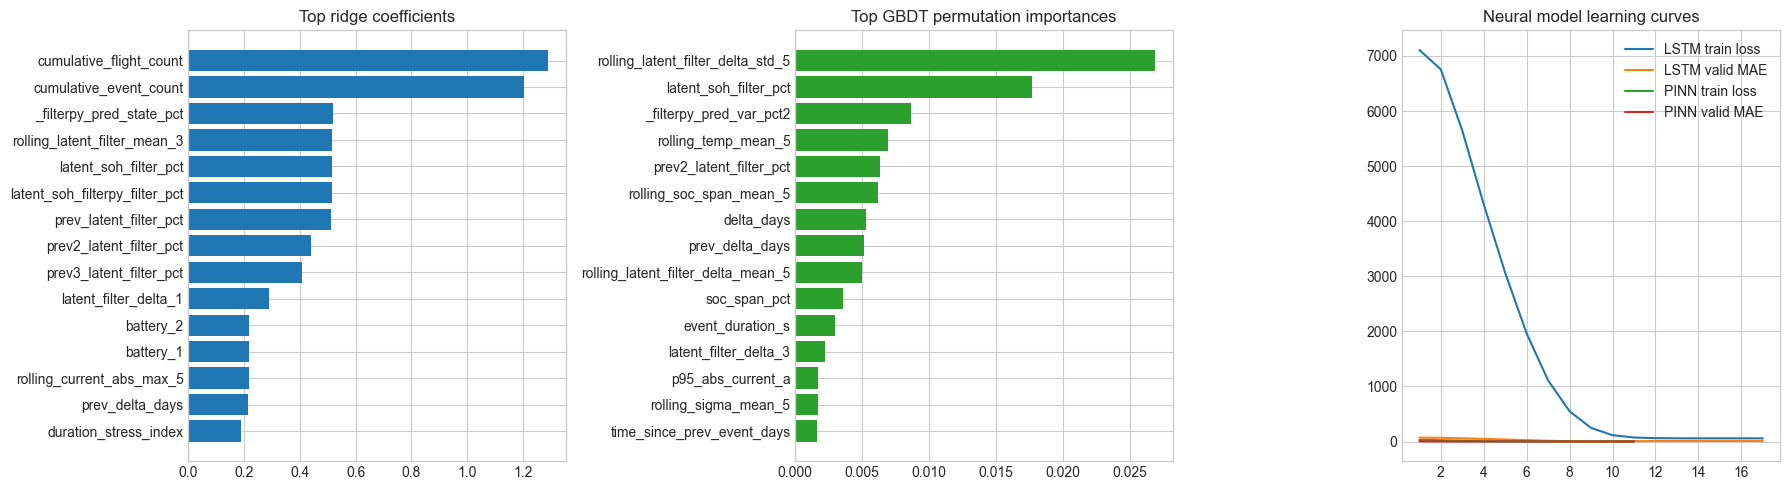

In [27]:
best_ridge_artifact = model_artifacts["ridge_raw_plus_latent_plus_history"]
ridge_coef_df = (
    pd.DataFrame(
        {
            "feature": best_ridge_artifact["feature_names"],
            "coef": best_ridge_artifact["model"].coef_,
            "abs_coef": np.abs(best_ridge_artifact["model"].coef_),
        }
    )
    .sort_values("abs_coef", ascending=False)
)
display(ridge_coef_df.head(25).round(4))

gbdt_artifact = model_artifacts["gbdt_raw_plus_latent_plus_history"]
gbdt_perm = permutation_importance(
    gbdt_artifact["model"],
    gbdt_artifact["test_frame"],
    gbdt_artifact["test_target_level"] - gbdt_artifact["test_current"],
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
)
gbdt_importance_df = (
    pd.DataFrame(
        {
            "feature": gbdt_artifact["feature_names"],
            "importance_mean": gbdt_perm.importances_mean,
            "importance_std": gbdt_perm.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
)
display(gbdt_importance_df.head(25).round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].barh(ridge_coef_df.head(15)["feature"][::-1], ridge_coef_df.head(15)["abs_coef"][::-1], color="#1f77b4")
axes[0].set_title("Top ridge coefficients")

axes[1].barh(gbdt_importance_df.head(15)["feature"][::-1], gbdt_importance_df.head(15)["importance_mean"][::-1], color="#2ca02c")
axes[1].set_title("Top GBDT permutation importances")

if not lstm_history_df.empty:
    axes[2].plot(lstm_history_df["epoch"], lstm_history_df["train_loss"], label="LSTM train loss", color="#1f77b4")
    axes[2].plot(lstm_history_df["epoch"], lstm_history_df["valid_mae"], label="LSTM valid MAE", color="#ff7f0e")
if not pinn_history_df.empty:
    axes[2].plot(pinn_history_df["epoch"], pinn_history_df["train_loss"], label="PINN train loss", color="#2ca02c")
    axes[2].plot(pinn_history_df["epoch"], pinn_history_df["valid_mae"], label="PINN valid MAE", color="#d62728")
axes[2].set_title("Neural model learning curves")
axes[2].legend(loc="best")
fig.tight_layout()


## 12. Forecast plots

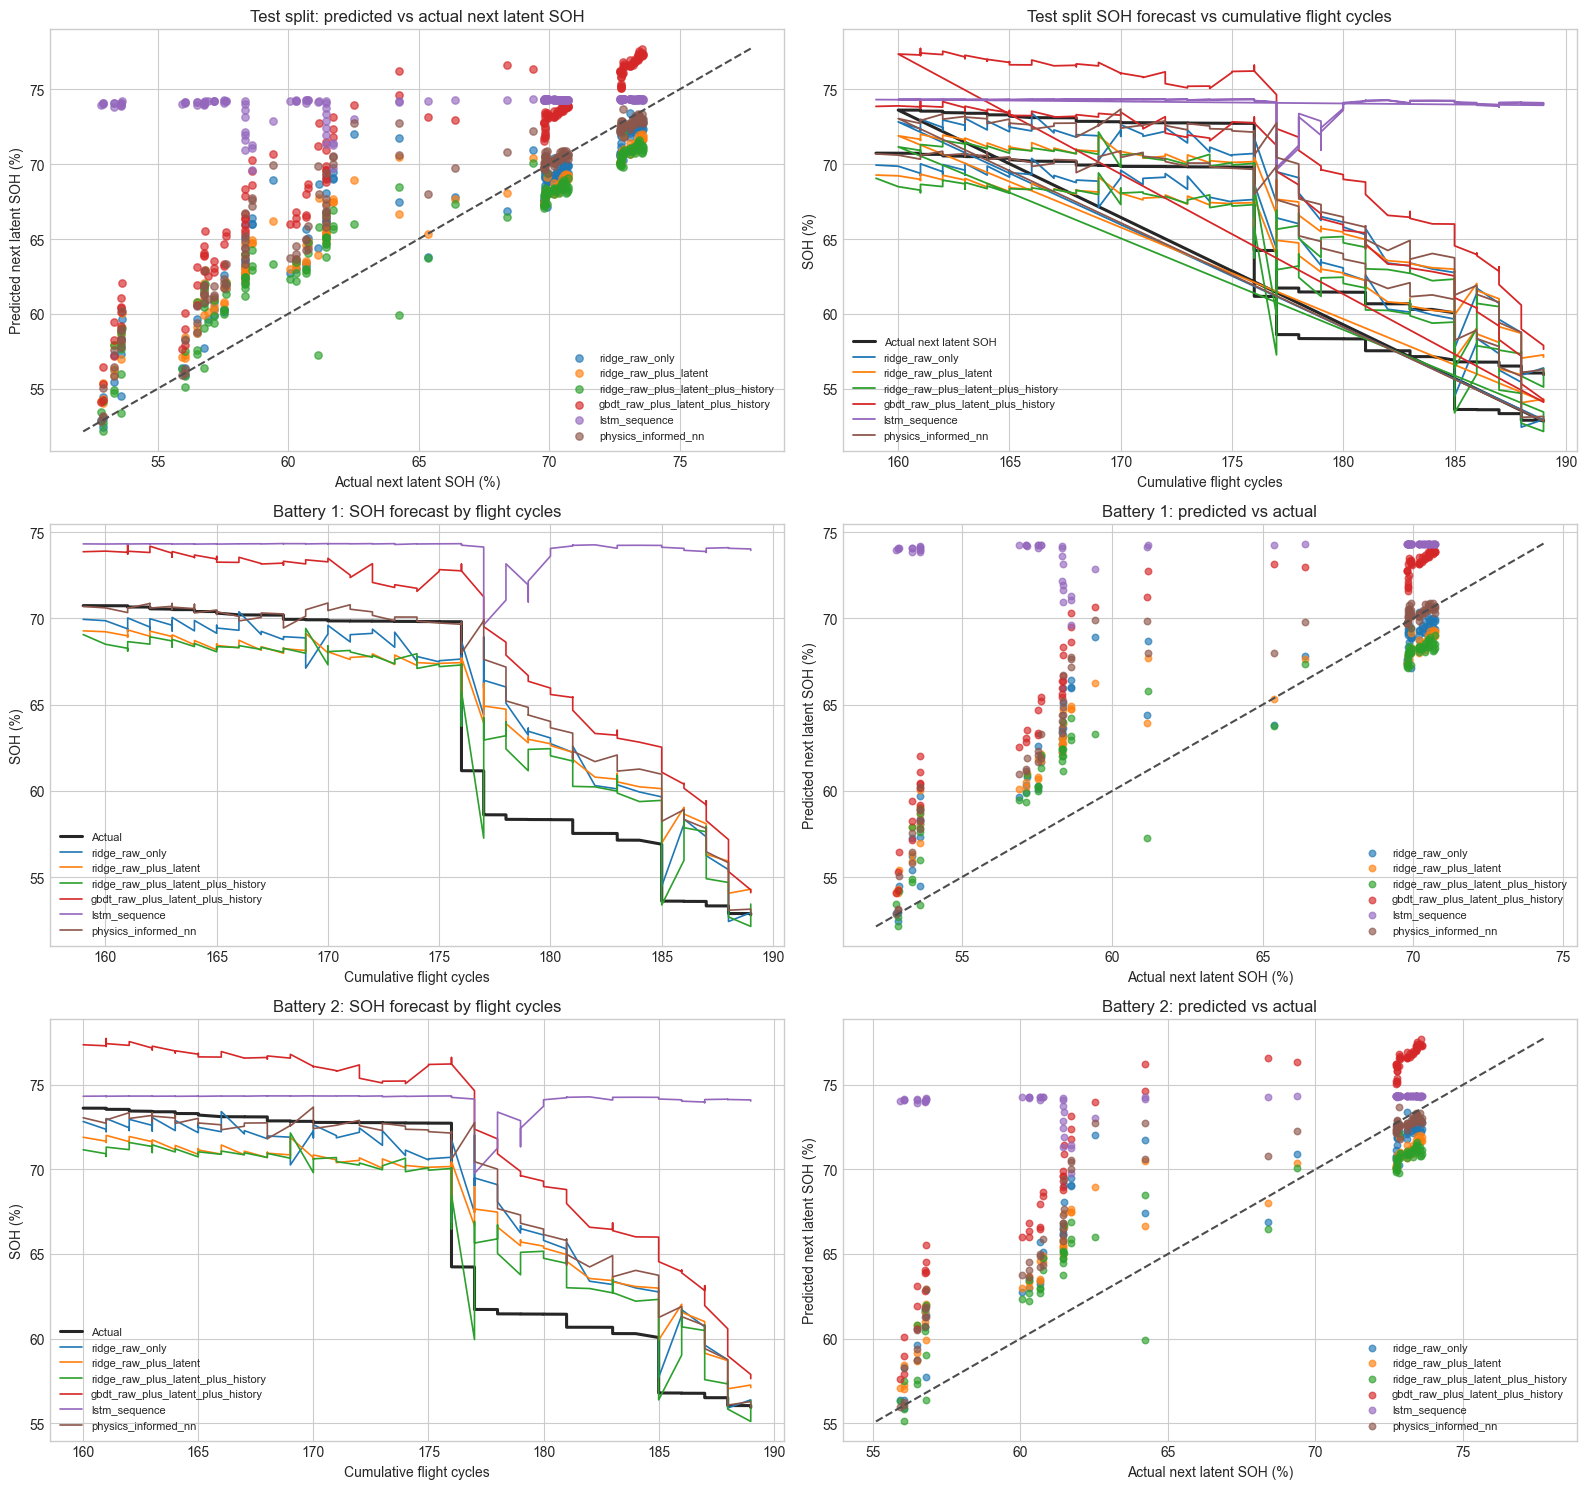

In [28]:
test_plot_df = benchmark_df.loc[benchmark_df["split"].eq("test")].copy().sort_values(["battery_id", "cumulative_flight_count", "event_datetime"])
plot_models = [
    "ridge_raw_only",
    "ridge_raw_plus_latent",
    "ridge_raw_plus_latent_plus_history",
    "gbdt_raw_plus_latent_plus_history",
    "lstm_sequence",
    "physics_informed_nn",
]
plot_models = [c for c in plot_models if c in test_plot_df.columns]

battery_ids = sorted(test_plot_df["battery_id"].dropna().unique().tolist())
nrows = 1 + len(battery_ids)
fig, axes = plt.subplots(nrows, 2, figsize=(16, 5 * nrows))
axes = np.atleast_2d(axes)

scatter_ax = axes[0, 0]
chron_ax = axes[0, 1]
for model_col in plot_models:
    sub = test_plot_df.loc[test_plot_df[model_col].notna()]
    scatter_ax.scatter(
        sub["next_latent_soh_smooth_pct"],
        sub[model_col],
        alpha=0.65,
        s=28,
        label=model_col,
    )
diagonal_low = min(test_plot_df["next_latent_soh_smooth_pct"].min(), *(test_plot_df[c].min() for c in plot_models if test_plot_df[c].notna().any()))
diagonal_high = max(test_plot_df["next_latent_soh_smooth_pct"].max(), *(test_plot_df[c].max() for c in plot_models if test_plot_df[c].notna().any()))
scatter_ax.plot([diagonal_low, diagonal_high], [diagonal_low, diagonal_high], linestyle="--", color="0.3")
scatter_ax.set_title("Test split: predicted vs actual next latent SOH")
scatter_ax.set_xlabel("Actual next latent SOH (%)")
scatter_ax.set_ylabel("Predicted next latent SOH (%)")
scatter_ax.legend(loc="best", fontsize=8)

chron_ax.plot(test_plot_df["cumulative_flight_count"], test_plot_df["next_latent_soh_smooth_pct"], linewidth=2.2, color="0.15", label="Actual next latent SOH")
for model_col in plot_models:
    chron_ax.plot(test_plot_df["cumulative_flight_count"], test_plot_df[model_col], linewidth=1.3, label=model_col)
chron_ax.set_title("Test split SOH forecast vs cumulative flight cycles")
chron_ax.set_xlabel("Cumulative flight cycles")
chron_ax.set_ylabel("SOH (%)")
chron_ax.legend(loc="best", fontsize=8)

for row_idx, battery_id in enumerate(battery_ids, start=1):
    battery_df = test_plot_df.loc[test_plot_df["battery_id"].eq(battery_id)].copy().sort_values(["cumulative_flight_count", "event_datetime"])
    ax_left = axes[row_idx, 0]
    ax_right = axes[row_idx, 1]
    ax_left.plot(battery_df["cumulative_flight_count"], battery_df["next_latent_soh_smooth_pct"], linewidth=2.2, color="0.15", label="Actual")
    for model_col in plot_models:
        ax_left.plot(battery_df["cumulative_flight_count"], battery_df[model_col], linewidth=1.2, label=model_col)
    ax_left.set_title(f"Battery {battery_id}: SOH forecast by flight cycles")
    ax_left.set_xlabel("Cumulative flight cycles")
    ax_left.set_ylabel("SOH (%)")
    ax_left.legend(loc="best", fontsize=8)

    for model_col in plot_models:
        sub = battery_df.loc[battery_df[model_col].notna()]
        ax_right.scatter(sub["next_latent_soh_smooth_pct"], sub[model_col], alpha=0.65, s=22, label=model_col)
    low = min(battery_df["next_latent_soh_smooth_pct"].min(), *(battery_df[c].min() for c in plot_models if battery_df[c].notna().any()))
    high = max(battery_df["next_latent_soh_smooth_pct"].max(), *(battery_df[c].max() for c in plot_models if battery_df[c].notna().any()))
    ax_right.plot([low, high], [low, high], linestyle="--", color="0.3")
    ax_right.set_title(f"Battery {battery_id}: predicted vs actual")
    ax_right.set_xlabel("Actual next latent SOH (%)")
    ax_right.set_ylabel("Predicted next latent SOH (%)")
    ax_right.legend(loc="best", fontsize=8)

fig.tight_layout()


## 13. Save outputs

In [29]:
benchmark_df.to_csv(OUTPUT_DIR / "multimodel_predictions.csv", index=False)
model_metrics.to_csv(OUTPUT_DIR / "multimodel_metrics_all_rows.csv", index=False)
full_available_metrics.to_csv(OUTPUT_DIR / "multimodel_metrics_by_available_predictions.csv", index=False)
common_subset_metrics.to_csv(OUTPUT_DIR / "multimodel_metrics_common_subset.csv", index=False)
ridge_coef_df.to_csv(OUTPUT_DIR / "ridge_history_coefficients.csv", index=False)
gbdt_importance_df.to_csv(OUTPUT_DIR / "gbdt_history_permutation_importance.csv", index=False)
corr_df.to_csv(OUTPUT_DIR / "feature_correlation_with_next_delta.csv", index=True)
lstm_history_df.to_csv(OUTPUT_DIR / "lstm_learning_curve.csv", index=False)
pinn_history_df.to_csv(OUTPUT_DIR / "pinn_learning_curve.csv", index=False)

print("Saved outputs to", OUTPUT_DIR)


Saved outputs to /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/output/multimodel_benchmark_plane_166


## 14. Interpretation

In [30]:
display(common_subset_metrics.round(4))

def get_metric(df: pd.DataFrame, split_name: str, model_name: str, metric_name: str):
    if df.empty:
        return np.nan
    sub = df.loc[df["eval_split"].eq(split_name) & df["model"].eq(model_name), metric_name]
    return float(sub.iloc[0]) if len(sub) else np.nan

if not common_subset_metrics.empty:
    test_metrics = common_subset_metrics.loc[common_subset_metrics["eval_split"].eq("test")].sort_values("level_mae")
    holdout_metrics = common_subset_metrics.loc[common_subset_metrics["eval_split"].eq("holdout")].sort_values("level_mae")
    if not test_metrics.empty:
        best_test = test_metrics.iloc[0]
        print(f"Best common-subset test model: {best_test['model']} (MAE={best_test['level_mae']:.4f}, RMSE={best_test['level_rmse']:.4f}, R2={best_test['level_r2']:.4f})")
        print("Top test models by level MAE:")
        display(test_metrics[["model", "level_mae", "level_rmse", "level_r2", "delta_r2"]].head(5).round(4))

        raw_mae = get_metric(common_subset_metrics, "test", "ridge_raw_only", "level_mae")
        latent_mae = get_metric(common_subset_metrics, "test", "ridge_raw_plus_latent", "level_mae")
        history_mae = get_metric(common_subset_metrics, "test", "ridge_raw_plus_latent_plus_history", "level_mae")
        elastic_history_mae = get_metric(common_subset_metrics, "test", "elastic_raw_plus_latent_plus_history", "level_mae")
        pinn_mae = get_metric(common_subset_metrics, "test", "physics_informed_nn", "level_mae")
        lstm_mae = get_metric(common_subset_metrics, "test", "lstm_sequence", "level_mae")

        if np.isfinite(raw_mae) and np.isfinite(latent_mae):
            delta = latent_mae - raw_mae
            direction = "improves on" if delta < 0 else "underperforms"
            print(f"On the test split, adding causal latent features to the raw ridge model {direction} the raw-only baseline by {abs(delta):.4f} MAE.")
        if np.isfinite(raw_mae) and np.isfinite(history_mae):
            delta = history_mae - raw_mae
            direction = "improves on" if delta < 0 else "underperforms"
            print(f"The ridge model with latent + history features {direction} the raw-only ridge by {abs(delta):.4f} MAE.")
        if np.isfinite(history_mae) and np.isfinite(elastic_history_mae):
            delta = elastic_history_mae - history_mae
            direction = "better" if delta < 0 else "worse"
            print(f"Elastic net history model is {direction} than ridge history by {abs(delta):.4f} MAE, suggesting {'useful regularized sparsity' if delta < 0 else 'ridge remains the safer linear choice'}.")
        if np.isfinite(lstm_mae) and np.isfinite(history_mae):
            delta = lstm_mae - history_mae
            direction = "outperforms" if delta < 0 else "lags"
            print(f"The LSTM {direction} the engineered-history ridge by {abs(delta):.4f} MAE on the test split.")
        if np.isfinite(pinn_mae) and np.isfinite(history_mae):
            delta = pinn_mae - history_mae
            direction = "outperforms" if delta < 0 else "lags"
            print(f"The physics-informed network {direction} the ridge history model by {abs(delta):.4f} MAE on the test split.")

    if not holdout_metrics.empty:
        best_holdout = holdout_metrics.iloc[0]
        print(f"Best common-subset holdout model: {best_holdout['model']} (MAE={best_holdout['level_mae']:.4f}, RMSE={best_holdout['level_rmse']:.4f}, R2={best_holdout['level_r2']:.4f})")
        print("Holdout results indicate whether the learned relationship transfers to another plane; strongly negative R2 means that the split remains difficult even if MAE looks modest.")

print("Interpretation guidance:")
print("- If history-enhanced linear models beat raw-only and latent-only models, most of the forecasting value is coming from explicit transition context rather than from the latent state alone.")
print("- If the LSTM fails to beat the engineered-history models, the sequence signal is probably already captured by the lag and rolling features, or the sample size is too small for sequence training to pay off.")
print("- If the physics-informed model is competitive on holdout, its degradation-structure constraint is helping robustness; if it lags badly, the imposed structure is too simple for the data.")
print("- Use the coefficient and permutation-importance tables to identify which cycle-count, lag, and stress features are carrying the forecast.")


,model,eval_split,coverage_rows,n,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,train,751,751,2.5865,2.9368,0.8556,2.5865,2.9368,-0.3327
1,ridge_raw_only,train,751,751,1.7405,2.2182,0.9176,1.7405,2.2182,0.2397
2,ridge_raw_plus_latent,train,751,751,0.9597,1.2468,0.9740,0.9597,1.2468,0.7598
3,elastic_raw_plus_latent_plus_history,train,751,751,1.3774,1.7465,0.9489,1.3774,1.7465,0.5286
4,ridge_raw_plus_latent_plus_history,train,751,751,0.7901,1.0095,0.9829,0.7901,1.0095,0.8425
5,gbdt_raw_plus_latent_plus_history,train,751,751,0.0728,0.0980,0.9998,0.0728,0.0980,0.9985
6,lstm_sequence,train,751,751,10.1055,12.6188,-1.6659,10.1055,12.6188,-23.6054
7,physics_informed_nn,train,751,751,2.2251,2.8727,0.8618,2.2251,2.8727,-0.2752
8,naive_zero_delta,valid,166,166,1.9708,2.0151,-0.6547,1.9708,2.0151,-21.9898
9,ridge_raw_only,valid,166,166,0.6245,0.7994,0.7396,0.6245,0.7994,-2.6178


Best common-subset test model: elastic_raw_plus_latent_plus_history (MAE=2.3757, RMSE=3.5092, R2=0.7524)
Top test models by level MAE:


,model,level_mae,level_rmse,level_r2,delta_r2
19,elastic_raw_plus_latent_plus_history,2.3757,3.5092,0.7524,-0.5745
23,physics_informed_nn,2.4178,3.6894,0.7263,-0.7404
17,ridge_raw_only,2.4488,3.2877,0.7826,-0.3820
20,ridge_raw_plus_latent_plus_history,2.5518,2.7902,0.8434,0.0046
18,ridge_raw_plus_latent,2.8505,3.2190,0.7916,-0.3248


On the test split, adding causal latent features to the raw ridge model underperforms the raw-only baseline by 0.4017 MAE.
The ridge model with latent + history features underperforms the raw-only ridge by 0.1030 MAE.
Elastic net history model is better than ridge history by 0.1761 MAE, suggesting useful regularized sparsity.
The LSTM lags the engineered-history ridge by 5.8139 MAE on the test split.
The physics-informed network outperforms the ridge history model by 0.1340 MAE on the test split.
Best common-subset holdout model: gbdt_raw_plus_latent_plus_history (MAE=0.3944, RMSE=0.5122, R2=-2.0833)
Holdout results indicate whether the learned relationship transfers to another plane; strongly negative R2 means that the split remains difficult even if MAE looks modest.
Interpretation guidance:
- If history-enhanced linear models beat raw-only and latent-only models, most of the forecasting value is coming from explicit transition context rather than from the latent state alone.
- If th